In [3]:
#You might need to install this
!python -m pip install git+https://github.com/afeinstein20/stella/

  Cloning https://github.com/afeinstein20/stella/ to /tmp/pip-req-build-qlhi4b48
  Running command git clone --filter=blob:none --quiet https://github.com/afeinstein20/stella/ /tmp/pip-req-build-qlhi4b48
  Resolved https://github.com/afeinstein20/stella/ to commit 05c5e4bf5814385e91aa902e069841e94b1925a0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 51.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 32.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 45

In [1]:
import tensorflow as tf
print(tf.__version__)

2026-03-18 20:39:28.251569: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-18 20:39:30.628403: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2.16.1


In [2]:
import os, sys
# ===== 指定使用哪块 GPU =====
# 改成 "0" 表示第 1 块物理 GPU
# 改成 "1" 表示第 2 块物理 GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import tensorflow as tf

# 可选：避免一上来占满全部显存
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
gpus = tf.config.list_physical_devices('GPU')
print("Detected GPUs:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is ready.")
    except RuntimeError as e:
        print("GPU setup error:", e)
else:
    print("No GPU detected. Training will run on CPU.")
import stella
from astropy.io import ascii
import numpy as np
from tqdm import tqdm_notebook
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 20

CUDA_VISIBLE_DEVICES: 1
Detected GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is ready.


/home/yangz2/anaconda3/envs/space/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Read in Guenther et al (2020) data from Vizier

In [3]:
star_table = ascii.read('./A3/table2.dat',readme='./A3/ReadMe')
flare_table = ascii.read('./A3/table1.dat',readme='./A3/ReadMe')
flare_table.write('./A3/Guenther_2020_flare_catalog.csv', format='csv', overwrite=True) 

Download lightcurves from TESS corresponding to the peak times of labelled flares (tpeak)

In [ ]:
# download = stella.DownloadSets(fn_dir='./A3/lightcurves/')
# download.download_catalog()
# download.download_lightcurves()
# ds = stella.FlareDataSet(downloadSet=download, cadences=200)
# download = stella.DownloadSets(fn_dir='./A3/lightcurves/')
# download.flare_table = flare_table
# download.download_lightcurves()
# ds = stella.FlareDataSet(downloadSet=download)

 17%|█▋        | 205/1228 [29:17<2:26:09,  8.57s/it]


ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

If lightcurves already downloaded, one can use them.

In [ ]:
ds = stella.FlareDataSet(fn_dir='/home/yangz2/code/space_universe/data/A3/lightcurves',
                         catalog='./A3/Guenther_2020_flare_catalog.csv',
                         cadences=200, frac_balance=0.60,
                         training=0.80, validation=0.90)

Reading in training set files.


100%|██████████| 1613/1613 [00:03<00:00, 409.56it/s]


8694 positive classes (flare)
53179 negative classes (no flare)
16.0% class imbalance



Next the data needs to be cleaned from NaNs.

In [5]:
#print(ds.train_data.shape)
isfin = np.isfinite(ds.train_data)
shp = ds.train_data.shape
ds.train_data = np.asarray([ds.train_data[i,...] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.train_labels = np.asarray([ds.train_labels[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])

isfin = np.isfinite(ds.training_matrix)
shp = ds.training_ids.shape
ds.training_matrix = np.asarray([ds.training_matrix[i,...] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.training_peaks = np.asarray([ds.training_peaks[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.training_ids = np.asarray([ds.training_ids[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])

isfin = np.isfinite(ds.val_data)
shp = ds.val_ids.shape
ds.val_data = np.asarray([ds.val_data[i,...] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.val_tpeaks = np.asarray([ds.val_tpeaks[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.val_ids = np.asarray([ds.val_ids[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])
ds.val_labels = np.asarray([ds.val_labels[i] for i in range(shp[0]) if np.min(isfin[i,...])==True])



Checking that the labelled data looks ok.

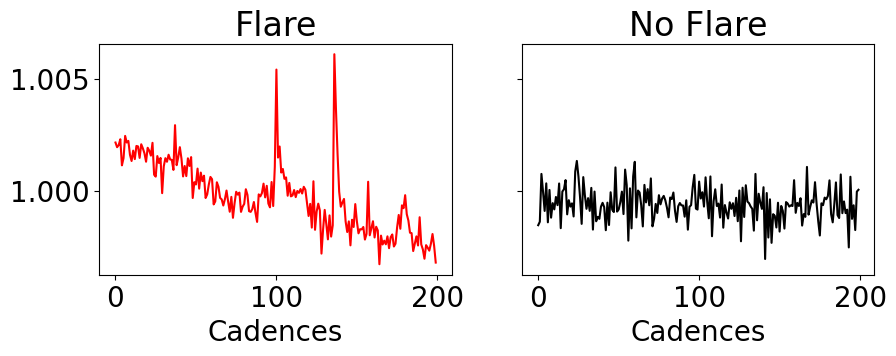

In [6]:
ind_pc = np.where(ds.train_labels==1)[0] # Flares
ind_nc = np.where(ds.train_labels==0)[0] # No flares

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,3), 
                               sharex=True, sharey=True)
ax1.plot(ds.train_data[ind_pc[10]], 'r')
ax1.set_title('Flare')
ax1.set_xlabel('Cadences')
ax2.plot(ds.train_data[ind_nc[10]], 'k')
ax2.set_title('No Flare')
ax2.set_xlabel('Cadences');

Creating a CNN model

In [7]:
# #Create your CNN
# import keras
# keras.backend.clear_session()
# model = keras.models.Sequential()
# #conv1D
# conv1D1=keras.layers.Conv1D(filters=16, kernel_size=10, activation='relu', padding='same', input_shape=(ds.cadences, 1))
# model.add(conv1D1)
# #Maxpooling
# maxpool=keras.layers.MaxPooling1D(pool_size=2)
# model.add(maxpool)
# #Dropout
# dropout=keras.layers.Dropout(0.2)
# model.add(dropout)
# conv1D2=keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same')
# model.add(conv1D2)
# maxpool=keras.layers.MaxPooling1D(pool_size=2)
# model.add(maxpool)
# dropout=keras.layers.Dropout(0.2)
# model.add(dropout)
# flat=keras.layers.Flatten()
# model.add(flat)
# dense32=keras.layers.Dense(32, activation='relu')
# model.add(dense32)
# dropout=keras.layers.Dropout(0.2)
# model.add(dropout)
# dense1=keras.layers.Dense(1, activation='sigmoid')
# model.add(dense1)

# Create a hybrid CNN + GRU model
import tensorflow as tf
from tensorflow import keras

keras.backend.clear_session()
tf.random.set_seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(ds.cadences, 1)),

    # Local pattern extraction
    keras.layers.Conv1D(
        filters=16,
        kernel_size=7,
        padding='same',
        activation='relu'
    ),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Dropout(0.1),

    keras.layers.Conv1D(
        filters=32,
        kernel_size=5,
        padding='same',
        activation='relu'
    ),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Dropout(0.1),

    # Temporal aggregation
    keras.layers.GRU(
        32,
        return_sequences=False,
        dropout=0.1,
        recurrent_dropout=0.0
    ),

    # Classifier
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()


2026-03-18 20:40:41.268198: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7678 MB memory:  -> device: 0, name: Tesla V100-PCIE-16GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,145 (39.63 KB)

 Trainable params: 10,145 (39.63 KB)

 Non-trainable params: 0 (0.00 B)

Creating the model and defining its output directory.

In [8]:
OUT_DIR='results/'
cnn = stella.ConvNN(output_dir=OUT_DIR, ds=ds, optimizer='Adam', layers=model.layers)

Training the model

In [10]:
cnn.train_models(seeds=5, epochs=200)
model.save(os.path.join(OUT_DIR, 'my_model_cnn_gru.h5'))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,145 (39.63 KB)

 Trainable params: 10,145 (39.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
760/760 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.8585 - loss: 0.4088 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8582 - val_loss: 0.4083 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/200
760/760 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8585 - loss: 0.4088 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8582 - val_loss: 0.4083 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/200
760/760 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8585 - loss: 0.4083 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8582 - val_loss: 0.4083 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/200
760/760 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8585 - loss: 0.4086 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8582 - val_loss: 0.4083 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/200
760/760 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8585 - loss: 0.

190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [11]:
cnn.history_table


accuracy_s0005,loss_s0005,precision_s0005,recall_s0005,val_accuracy_s0005,val_loss_s0005,val_precision_s0005,val_recall_s0005
float64,float64,float64,float64,float64,float64,float64,float64
0.8584981560707092,0.40878182649612427,0.0,0.0,0.8581793904304504,0.40831461548805237,0.0,0.0
0.8584981560707092,0.4087948501110077,0.0,0.0,0.8581793904304504,0.40832018852233887,0.0,0.0
0.8584981560707092,0.40826115012168884,0.0,0.0,0.8581793904304504,0.40833359956741333,0.0,0.0
0.8584981560707092,0.4085928499698639,0.0,0.0,0.8581793904304504,0.4083085358142853,0.0,0.0
0.8584981560707092,0.4084877669811249,0.0,0.0,0.8581793904304504,0.40832290053367615,0.0,0.0
0.8584981560707092,0.4087534546852112,0.0,0.0,0.8581793904304504,0.408355176448822,0.0,0.0
0.8584981560707092,0.409003347158432,0.0,0.0,0.8581793904304504,0.40835079550743103,0.0,0.0
0.8584981560707092,0.40864625573158264,0.0,0.0,0.8581793904304504,0.4083332121372223,0.0,0.0
0.8584981560707092,0.40864163637161255,0.0,0.0,0.8581793904304504,0.40832462906837463,0.0,0.0


In [13]:
import h5py, os
ens_path = "results/ensemble_s0005_i0200_b0.6.h5"
with h5py.File(ens_path, "r") as f:
    print("Root keys:", list(f.keys()))
    print("Has model_config:", "model_config" in f)

Root keys: ['model_weights', 'optimizer_weights']
Has model_config: False


In [14]:
import glob
cands = sorted(glob.glob("results/ensemble_s0005_i0200_b0.6.h5"))
cands[:5], len(cands)

(['results/ensemble_s0005_i0200_b0.6.h5'], 1)

In [15]:
import stella, pathlib, re, sys, inspect
pkg_path = pathlib.Path(stella.__file__).resolve().parent
print("stella package path:", pkg_path)

# Search for likely model builders
candidates = []
for p in pkg_path.rglob("*.py"):
    try:
        txt = p.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        continue
    if any(k in txt for k in ["Conv1D", "Sequentia", "build_model", "cnn", "Model("]):
        candidates.append(p)
print("Possible model files:")
for p in candidates:
    print(" -", p.relative_to(pkg_path))

stella package path: /home/yangz2/anaconda3/envs/space/lib/python3.11/site-packages/stella
Possible model files:
 - visualize.py
 - neural_network.py
 - tests/test_neural_network.py


In [17]:
import h5py                                                                                                                               
                                                                                                                                            
ens_path = "./results/ensemble_s0005_i0200_b0.6.h5"                                                                                       

with h5py.File(ens_path, "r") as f:                                                                                                       
  print("Root keys:", list(f.keys()))                                                                                                 
  has_model_config = "model_config" in f                                                                                                
  print("Has model_config:", has_model_config)                                                                                          

# 直接从模型权重推断输入维度                                                                                                              
def infer_cadences_from_h5(path):                                                                                                         
  with h5py.File(path, "r") as f:                                                                                                       
      dense_kernels = []                                                                                                                
      def visitor(name, obj):                                                                                                           
          # 修复: 不再查找 "kernel:0"，而是查找包含 "kernel" 且在 model_weights 下的                                                    
          if isinstance(obj, h5py.Dataset) and name.endswith("/kernel") and "model_weights" in name:                                    
              shape = tuple(obj.shape)                                                                                                  
              dense_kernels.append((name, shape))                                                                                       
      f.visititems(visitor)                                                                                                             

  print("Dense kernels:", dense_kernels)                                                                                                

  # 找到第一个 Dense 层的 kernel (shape 应该是 (input_dim, 32))                                                                         
  candidates = [(name, shape) for name, shape in dense_kernels if len(shape) == 2 and shape[1] == 32]                                 
  if not candidates:                                                                                                                    
      raise RuntimeError(f"No Dense kernel with shape (*, 32) found")                                                                   

  name, (X, out_units) = candidates[0]                                                                                                  

  # 对于 CNN-GRU 模型: 经过两次 pool_size=2 池化后是 X                                                                                  
  # 所以原始输入 cadences = X * 4                                                                                                     
  cadences = X * 4                                                                                                                      
  print(f"Inferred cadences from {name}: X={X} => cadences={cadences}")                                                                 
  return cadences                                                                                                                       

cadences = infer_cadences_from_h5(ens_path)                                                                                               
print(f"结果: {cadences}") 

Root keys: ['model_weights', 'optimizer_weights']
Has model_config: False
Dense kernels: [('model_weights/conv1d/sequential/conv1d/kernel', (7, 1, 16)), ('model_weights/conv1d_1/sequential/conv1d_1/kernel', (5, 16, 32)), ('model_weights/dense/sequential/dense/kernel', (32, 32)), ('model_weights/dense_1/sequential/dense_1/kernel', (32, 1)), ('model_weights/gru/sequential/gru/gru_cell/kernel', (32, 96))]
Inferred cadences from model_weights/dense/sequential/dense/kernel: X=32 => cadences=128
结果: 128


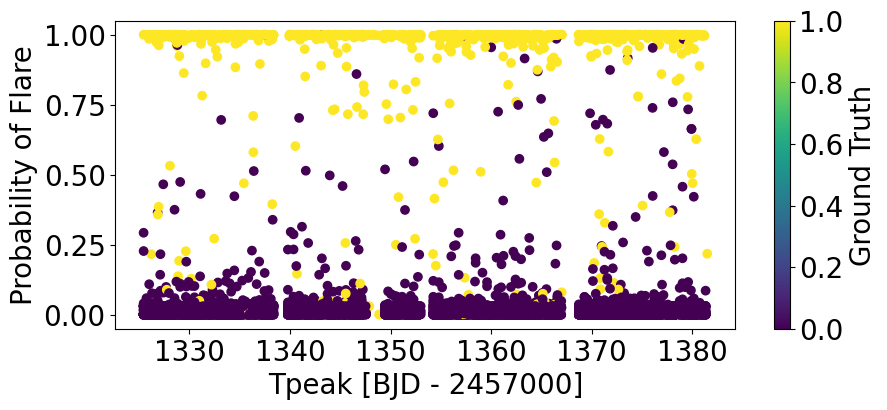

In [20]:
plt.figure(figsize=(10,4))
plt.scatter(cnn.val_pred_table['tpeak'], cnn.val_pred_table['pred_s0005'],
            c=cnn.val_pred_table['gt'], vmin=0, vmax=1)
plt.xlabel('Tpeak [BJD - 2457000]')
plt.ylabel('Probability of Flare')
plt.colorbar(label='Ground Truth');

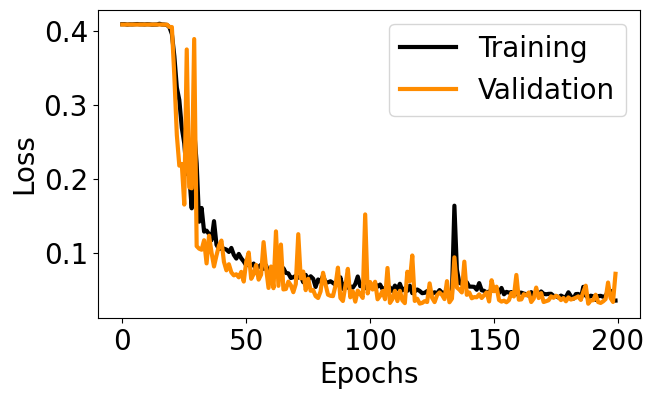

In [23]:
plt.figure(figsize=(7,4))
plt.plot(cnn.history_table['loss_s0005'], 'k', label='Training', lw=3)
plt.plot(cnn.history_table['val_loss_s0005'], 'darkorange', label='Validation', lw=3)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();

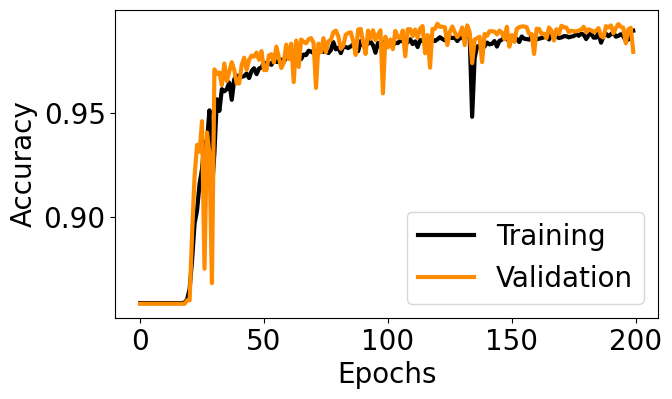

In [24]:
plt.figure(figsize=(7,4))
plt.plot(cnn.history_table['accuracy_s0005'], 'k', label='Training', lw=3)
plt.plot(cnn.history_table['val_accuracy_s0005'], 'darkorange', label='Validation', lw=3)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend();

In [25]:
#Training loss and accuracy
tacc=(np.mean(cnn.history_table['accuracy_s0005'][150:200]))
tloss=(np.mean(cnn.history_table['loss_s0005'][150:200]))
print(tloss,tacc)
vacc=(np.mean(cnn.history_table['val_accuracy_s0005'][150:200]))
vloss=(np.mean(cnn.history_table['val_loss_s0005'][150:200]))
print(vloss,vacc)

0.044268575012683865 0.9864931190013886
0.04158715702593327 0.9889511895179749


Grading section
===============
Please give your student number (student_number) for grading and scoring the results


In [26]:
student_number=101513496

Please give the **maximum of your training/validation loss** score as brmse and **minimum of training/validation accuracy** as acc for grading and scoring the results.

In [27]:
brmse=np.min([tloss,vloss])
bacc=np.min([tacc,vacc])

In [30]:
from datetime import datetime
current_time = datetime.now()

f = open("./A3/MyResults.txt", "w")
f.write("%s,%s,%f,%f\n" % (student_number,current_time,brmse,bacc))
f.close()
